In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [31]:
data = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Phase 1: Identify Categorical Variables

In [33]:
cat_cols = [col for col in data.columns if data[col].dtype in ['str', 'object']]
num_cols = [col for col in data.columns if data[col].dtype in ['int64', 'float64']]

print(cat_cols)
print(num_cols)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']
['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [ ]:
cat_df = data.select_dtypes(include=['object', 'str'])
cat_df

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),1840.75,No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,1990.5,No
7039,2234-XADUH,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),7362.9,No
7040,4801-JZAZL,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,346.45,No
7041,8361-LTMKD,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,306.6,Yes


In [35]:
num_df = data.select_dtypes(include=['int64', 'float64'])
num_df

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


### Phase 2: Frequency Tables

In [38]:
def frequency_table(col: pd.Series) -> pd.DataFrame:

    freq = col.value_counts()

    percent = (
        col.value_counts(normalize=True)
        * 100
    )

    table = pd.DataFrame(
        {
            'Count': freq,
            'Percent': percent.round(2)
        }
    )

    return table

In [46]:
table = frequency_table(data['Contract'])
print(table.columns)
print(table.index)
table

Index(['Count', 'Percent'], dtype='str')
Index(['Month-to-month', 'Two year', 'One year'], dtype='str', name='Contract')


,Count,Percent
Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91


### Phase 3: Relative Frequency

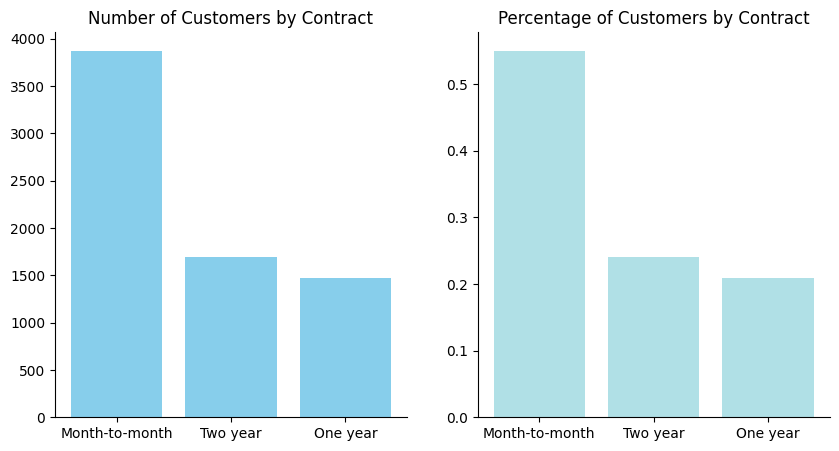

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))


contact_col = data['Contract']


axes[0].bar(
    x=contact_col.value_counts().index,
    height=contact_col.value_counts().values,
    color='skyblue'
)
axes[0].set_title('Number of Customers by Contract')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].bar(
    x=contact_col.value_counts().index,
    height=contact_col.value_counts(normalize=True).values,
    color='powderblue'
)
axes[1].set_title('Percentage of Customers by Contract')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

### Phase 4: Contingency Tables

`Question`
>> Does churn differ by contract type?

In [67]:
pd.crosstab(
    data['Contract'],
    data['Churn']
)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [70]:
(pd.crosstab(
    data['Contract'],
    data['Churn'],
    normalize='index'
) * 100).round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


### Phase 5: Grouped Bar Chart

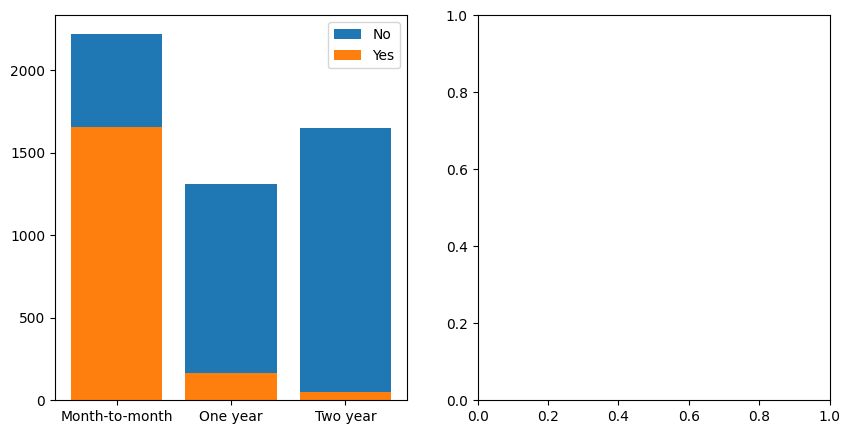

In [77]:
# contract_churn_data = pd.crosstab(
#     data['Contract'],
#     data['Churn'], 
#     # normalize=True
# ).plot(
#     kind='bar',
#     stacked=True
# )

contract_churn_data = pd.crosstab(
    data['Contract'],
    data['Churn'], 
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(
    x=contract_churn_data.index,
    height= contract_churn_data['No'],
    label='No'
)
axes[0].bar(
    x=contract_churn_data.index,
    height= contract_churn_data['Yes'],
    label='Yes'
)

axes[0].legend()

In [ ]:
https://chatgpt.com/c/6a265b6f-91a8-83eb-823b-045a5a7fe159